In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("CMS")

from llr_study.utils import *

In [2]:
%config InlineBackend.figure_format = 'retina'

In [ ]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = [
    'LLR_odd',
    'LLR_odd_combos2to5',
    'LLR_odd_combos6',
    'LLR_odd_combos7to12',
]
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = parse_UL_results_files(file_paths)

# Save to CSV for further analysis
# output_file = "combined_llr_results.csv"
# df.to_csv(output_file, index=False)
# print(f"\nResults saved to {output_file}")

Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd/fits_new/summary_results.txt...
  Found 87 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos2to5/fits_new/summary_results.txt...
  Found 1573 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos6/fits_new/summary_results.txt...
  Found 924 LLRs
Parsing /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/LLR_odd_combos7to12/fits_new/summary_results.txt...
  Found 1586 LLRs

Total LLRs parsed: 4170
LLR type distribution:
from_multivar    4083
from_1D            66
from_2D            17
from_3D             4
Name: llr_type, dtype: int64


/cvmfs/sft.cern.ch/lcg/views/LCG_105/x86_64-el9-gcc11-opt/lib/python3.9/site-packages/matplotlib/cbook.py:1072: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  x = np.asanyarray(x)


Scatter plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_scatterplot_by_type.pdf


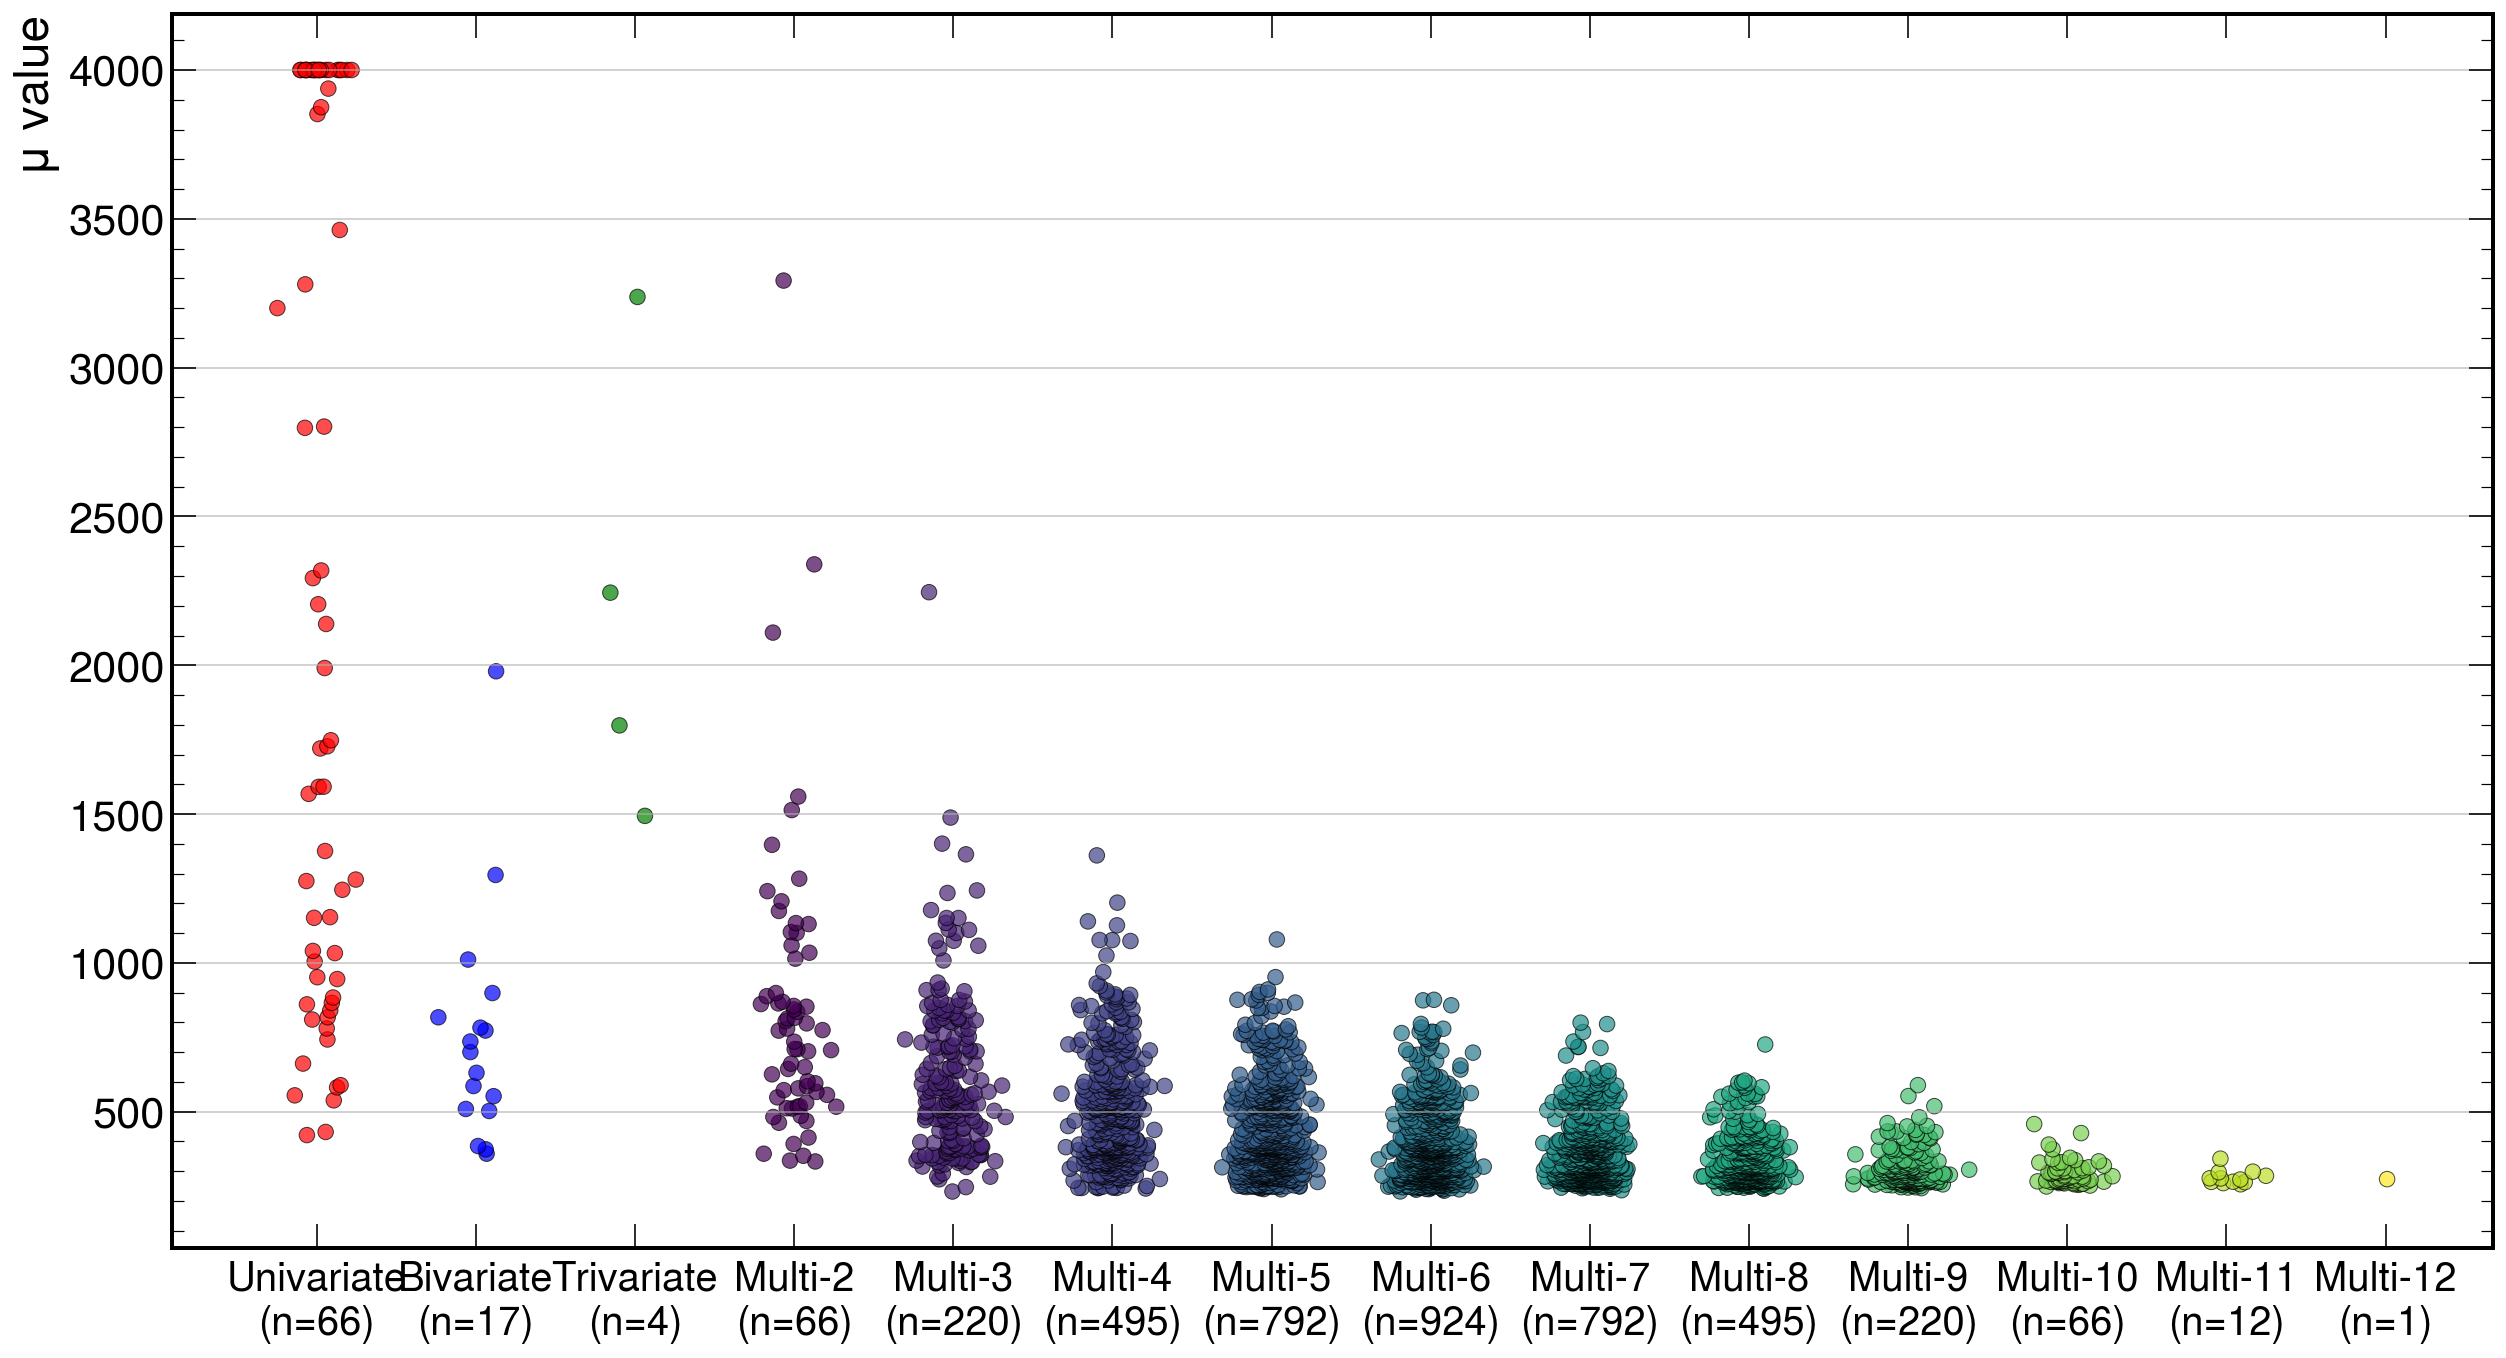

In [7]:
create_UL_scatter_plot_by_type(df, projectdir)

Descriptive box plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_boxplot_by_type.pdf


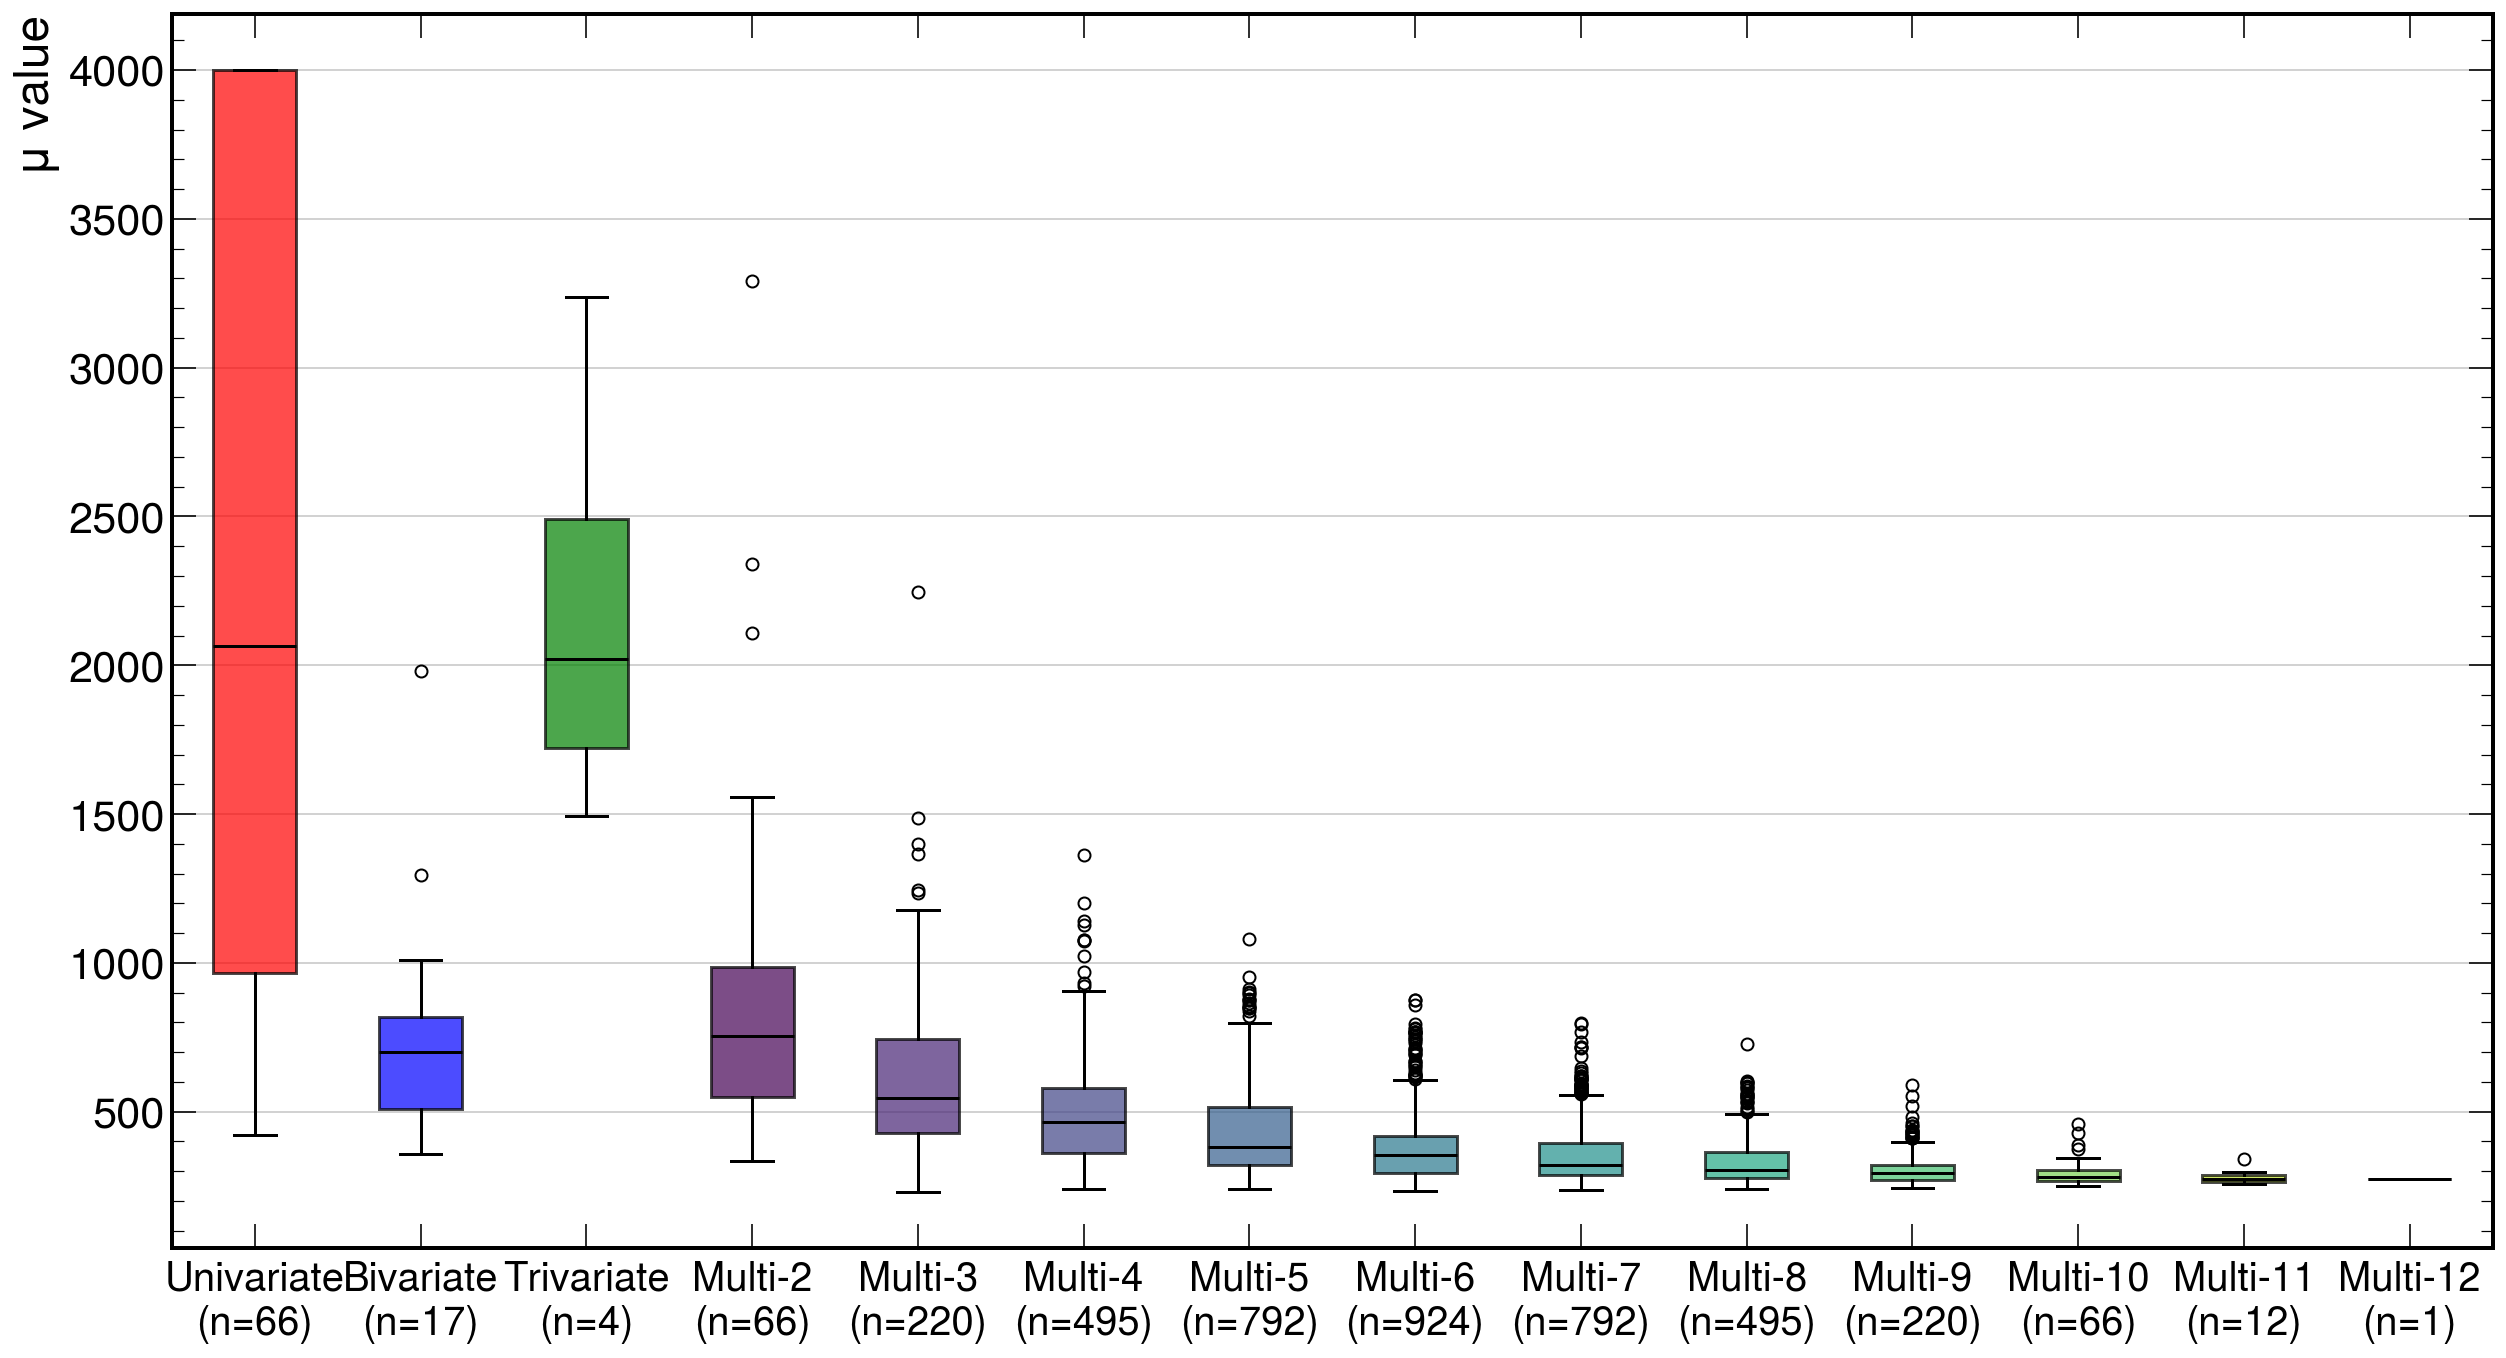

In [8]:
create_UL_box_plot_by_type(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_multivar_trend.pdf


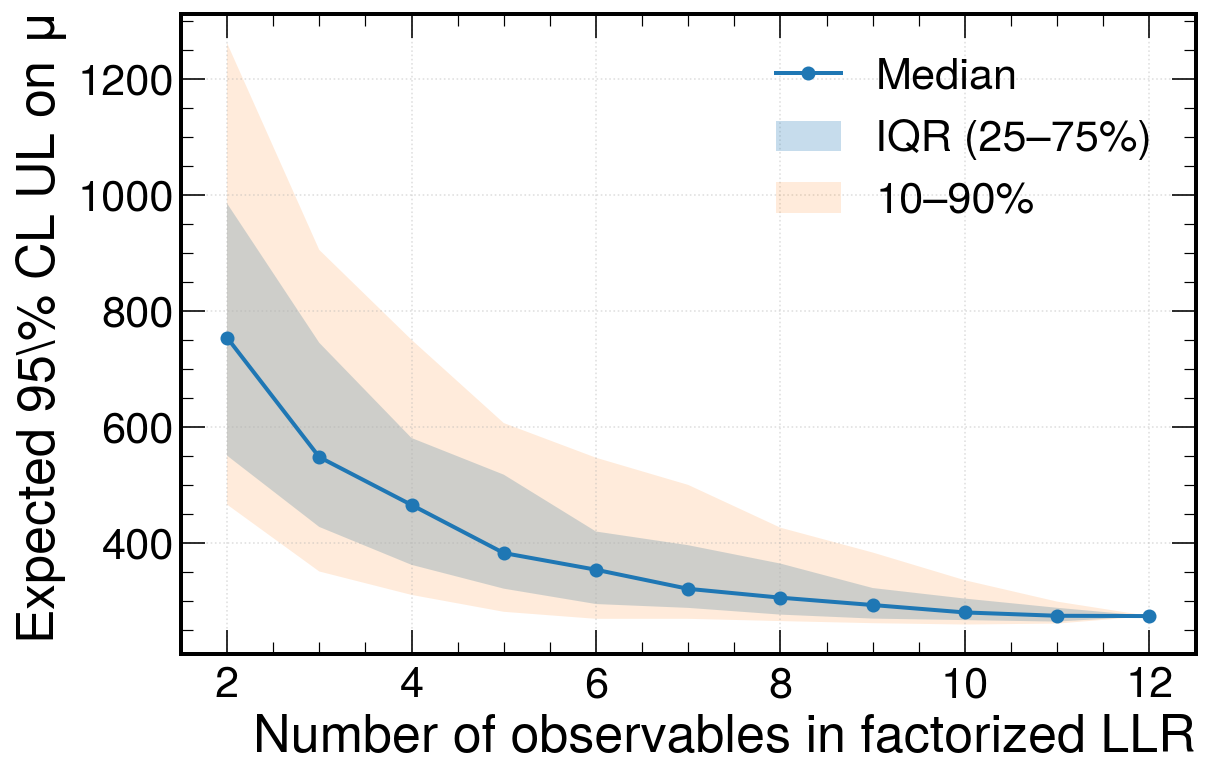

In [9]:
plot_multivar_trend(df, projectdir)

Hierarchical 1D plot saved to /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/hierarchical_1D_llrs.pdf


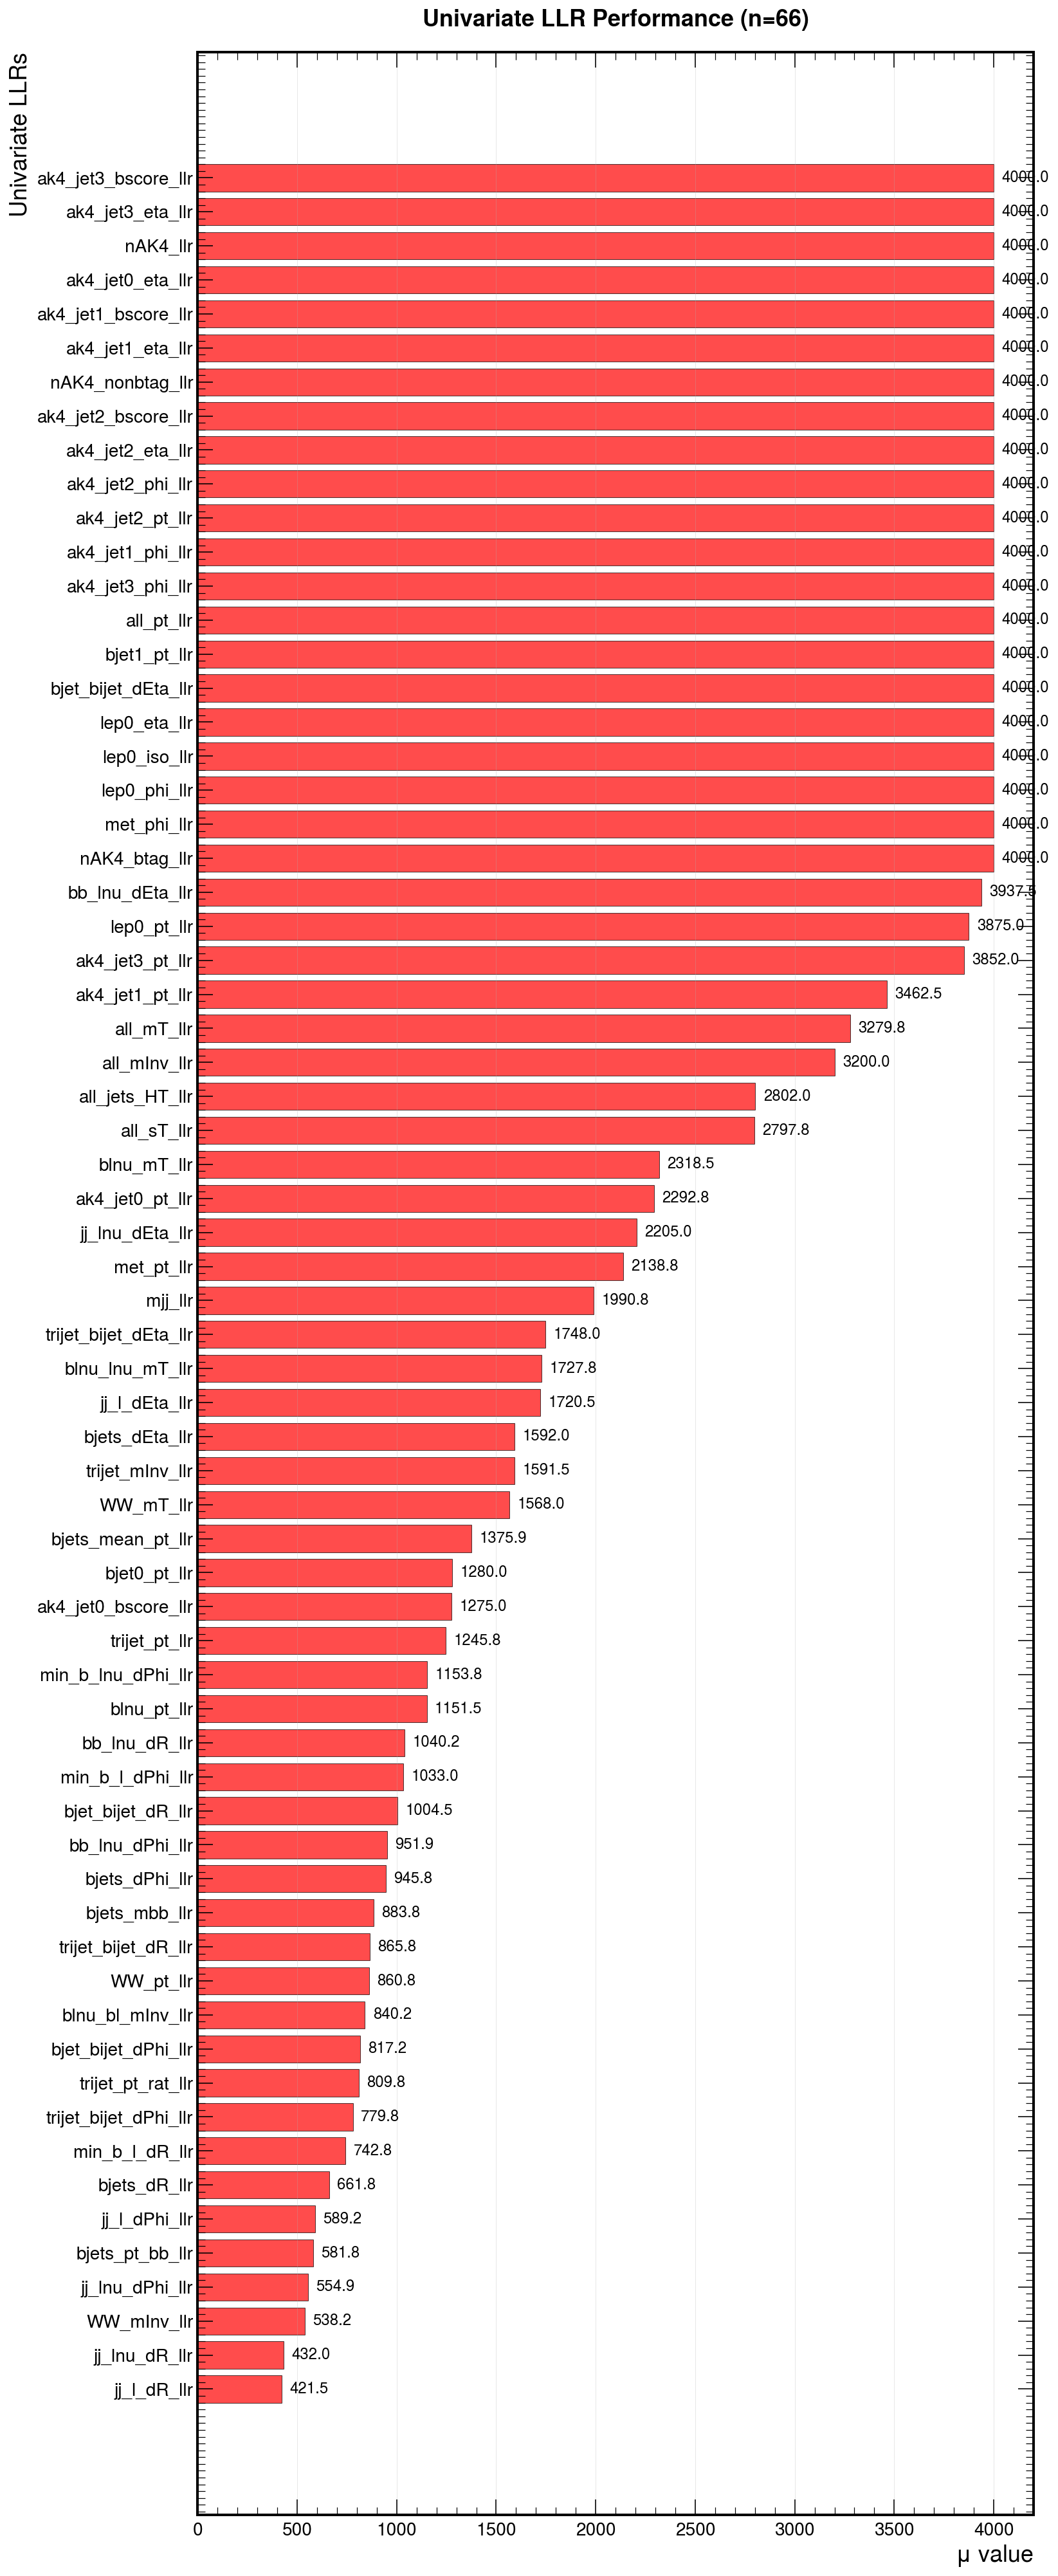

In [10]:
create_hierarchical_1D_plot(df, projectdir)

Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_global_scatter.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_variable_usage_top10.pdf
Saved /eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New/llr_greedy_chain.pdf


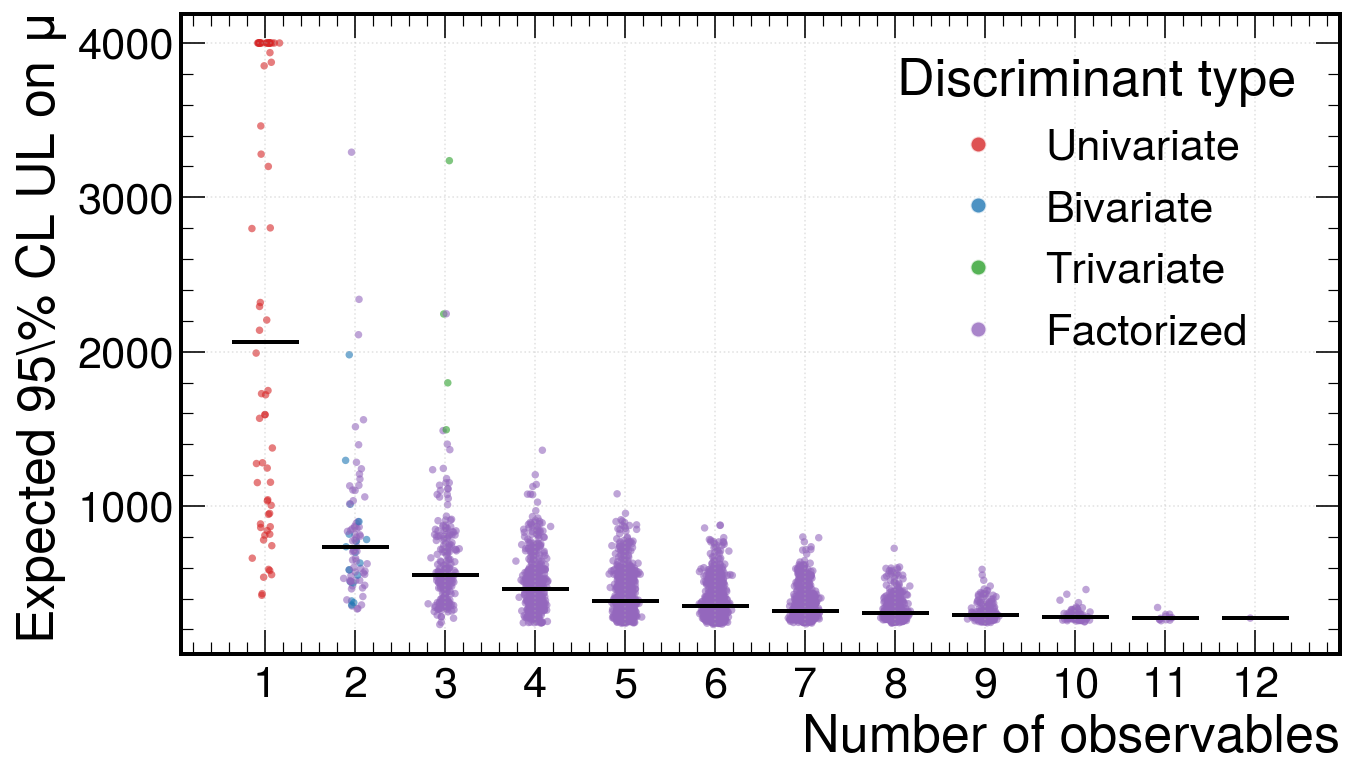

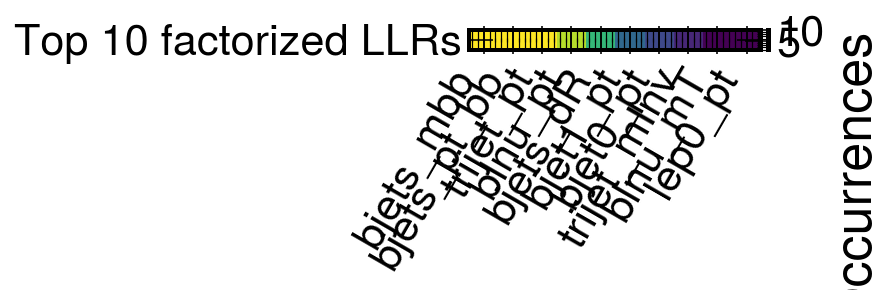

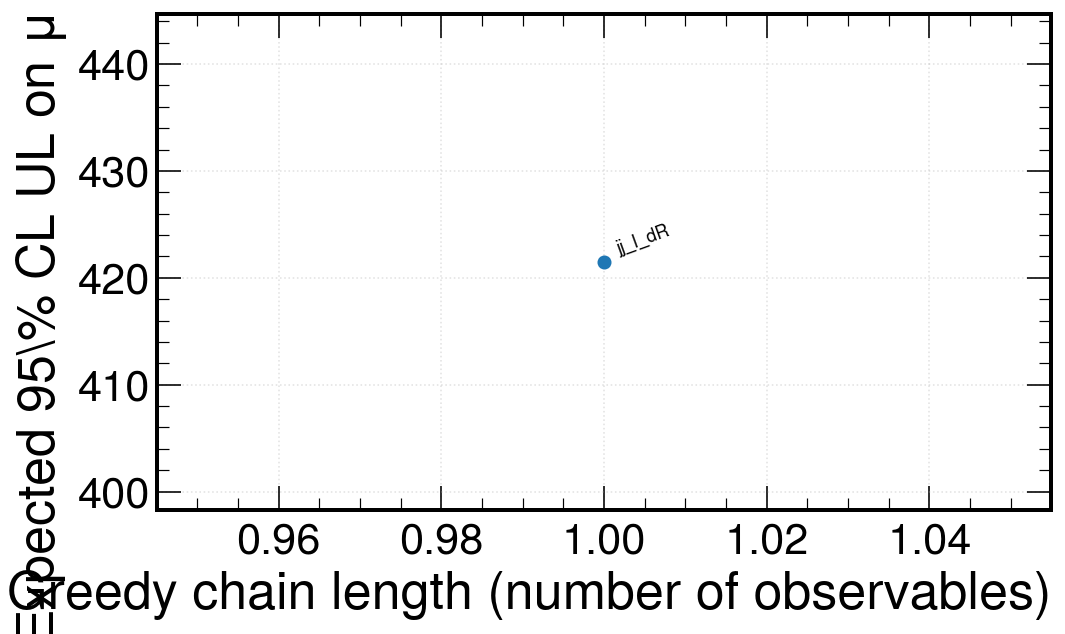

In [11]:
plot_global_scatter(df, projectdir)
plot_variable_usage_heatmap(df, projectdir, 10)
plot_greedy_chain(df, projectdir, max_k=10)

In [19]:
# Create a clean ranking DataFrame
from_1d_ranking = df[df['llr_type'] == 'from_1D'][['llr_name', 'mu_value']].copy()
from_1d_ranking = from_1d_ranking.sort_values('mu_value').reset_index(drop=True)
from_1d_ranking['rank'] = range(1, len(from_1d_ranking) + 1)
from_1d_ranking = from_1d_ranking[['rank', 'llr_name', 'mu_value']]

# Display
print(from_1d_ranking.to_string(index=False))

 rank              llr_name  mu_value
    1           jj_l_dR_llr  421.5000
    2         jj_lnu_dR_llr  432.0000
    3           WW_mInv_llr  538.2500
    4       jj_lnu_dPhi_llr  554.9375
    5       bjets_pt_bb_llr  581.7500
    6         jj_l_dPhi_llr  589.2500
    7          bjets_dR_llr  661.7500
    8        min_b_l_dR_llr  742.7500
    9 trijet_bijet_dPhi_llr  779.7500
   10     trijet_pt_rat_llr  809.7500
   11   bjet_bijet_dPhi_llr  817.2500
   12      blnu_bl_mInv_llr  840.2500
   13             WW_pt_llr  860.7500
   14   trijet_bijet_dR_llr  865.7500
   15         bjets_mbb_llr  883.7500
   16        bjets_dPhi_llr  945.7500
   17       bb_lnu_dPhi_llr  951.8750
   18     bjet_bijet_dR_llr 1004.5000
   19      min_b_l_dPhi_llr 1033.0000
   20         bb_lnu_dR_llr 1040.2500
   21           blnu_pt_llr 1151.5000
   22    min_b_lnu_dPhi_llr 1153.7500
   23         trijet_pt_llr 1245.7500
   24   ak4_jet0_bscore_llr 1275.0000
   25          bjet0_pt_llr 1280.0000
   26     bj

In [26]:
top_10_1d_llrs = from_1d_ranking['llr_name'][:10].to_list()
top_10_1d_llrs


['jj_l_dR_llr',
 'jj_lnu_dR_llr',
 'WW_mInv_llr',
 'jj_lnu_dPhi_llr',
 'bjets_pt_bb_llr',
 'jj_l_dPhi_llr',
 'bjets_dR_llr',
 'min_b_l_dR_llr',
 'trijet_bijet_dPhi_llr',
 'trijet_pt_rat_llr']

In [22]:
reserved = [
    'lep0_pt',                                      
    'bjets_mbb', 'bjets_dR', 'bjets_pt_bb', 'bjet0_pt', 'bjet1_pt',         # bjet-vars
    'blnu_mT', 'blnu_pt',                                                   # leptonic-top 
    'trijet_mInv', 'trijet_pt', 'trijet_pt_rat', 'trijet_bijet_dR'          # hadronic-top 
]
# Create the full LLR names by adding '_llr' suffix
reserved_llr_names = [var + '_llr' for var in reserved]

# Filter the ranking for only the reserved LLRs
reserved_ranking = from_1d_ranking[from_1d_ranking['llr_name'].isin(reserved_llr_names)].copy()

# Display the results
print(f"Ranking of Reserved LLRs ({len(reserved_ranking)} out of {len(reserved)} found):")
print("-" * 60)
for _, row in reserved_ranking.iterrows():
    print(f"{row['rank']:2d}. {row['llr_name']:<25} μ = {row['mu_value']:8.3f}")

# Check if any reserved LLRs are missing
missing_llrs = set(reserved_llr_names) - set(reserved_ranking['llr_name'])
if missing_llrs:
    print(f"\nMissing from 1D rankings: {missing_llrs}")

Ranking of Reserved LLRs (12 out of 12 found):
------------------------------------------------------------
 5. bjets_pt_bb_llr           μ =  581.750
 7. bjets_dR_llr              μ =  661.750
10. trijet_pt_rat_llr         μ =  809.750
14. trijet_bijet_dR_llr       μ =  865.750
15. bjets_mbb_llr             μ =  883.750
21. blnu_pt_llr               μ = 1151.500
23. trijet_pt_llr             μ = 1245.750
25. bjet0_pt_llr              μ = 1280.000
28. trijet_mInv_llr           μ = 1591.500
37. blnu_mT_llr               μ = 2318.500
44. lep0_pt_llr               μ = 3875.000
52. bjet1_pt_llr              μ = 4000.000
